In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
DATA_PATH =  "/content/drive/MyDrive/data"

In [4]:
IMG_SIZE = (300,300)
BATCH_SIZE = 32
# Ensure DATA_PATH is defined, e.g., DATA_PATH = './dataset'
# 1. Training Generator (WITH data augmentation)
# UPDATE YOUR TRAINING GENERATOR:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <-- ADD THIS
    # rescale=1./255,                        # <-- DELETE THIS
    rotation_range=30,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

# YOUR VAL GENERATOR IS ALREADY CORRECT:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# 3. Create flow from directory
train_gen = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42  # Use same seed to ensure splits don't overlap
)
val_gen = val_datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False, # Usually False for validation to keep labels in order
    seed=42        # Must match the training seed
)

Found 3914 images belonging to 4 classes.
Found 781 images belonging to 4 classes.


In [5]:
class_weights = {
    0: 1.3,   # damage
    1: 1.3,   # flood
    2: 1.8,   # normal
    3: 1.0    # wildfire
}

In [6]:
print(train_gen.num_classes)
print(train_gen.class_indices)

4
{'damage': 0, 'flood': 1, 'normal': 2, 'wildfire': 3}


In [8]:
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add the regularizer right here inside the Dense layer:
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

x = Dropout(0.6)(x) # Keeping your updated dropout

output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,              
        restore_best_weights=True
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,              
        min_lr=1e-6,
        verbose=1
    )
]

In [10]:
# STEP 1: Fully freeze the base_model and train JUST the dense head
for layer in base_model.layers:
    layer.trainable = False

# Compile with a relatively normal learning rate for the head
model.compile(
    optimizer=Adam(learning_rate=1e-3), # Standard LR for dense layers
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Training Top Layers...")
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15, 
)

# STEP 2: Unfreeze the last 40 layers and FINE-TUNE
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Re-compile with a VERY SMALL learning rate so we don't break the weights
model.compile(
    optimizer=Adam(learning_rate=1e-5), # Tiny LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Fine-Tuning Base Model...")
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=35,
    callbacks=callbacks # Put your EarlyStopping and ReduceLROnPlateau here
)


Training Top Layers...
Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 1688s 13s/step - accuracy: 0.8470 - loss: 1.0581 - precision: 0.9077 - recall: 0.7793 - val_accuracy: 0.9078 - val_loss: 0.8955 - val_precision: 0.9491 - val_recall: 0.8361
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9106 - loss: 0.8286 - precision: 0.9481 - recall: 0.8687 - val_accuracy: 0.8899 - val_loss: 0.8037 - val_precision: 0.9424 - val_recall: 0.8387
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9241 - loss: 0.7366 - precision: 0.9570 - recall: 0.8881 - val_accuracy: 0.9155 - val_loss: 0.6989 - val_precision: 0.9634 - val_recall: 0.8771
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9228 - loss: 0.6968 - precision: 0.9535 - recall: 0.8861 - val_accuracy: 0.9129 - val_loss: 0.6962 - val_precision: 0.9515 - val_recall: 0.8540
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9297 - loss: 0.6578 - precision: 0.9589 - recall: 0.8935 - val_a

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = val_gen.classes
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 863ms/step
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        98
           1       0.96      0.99      0.97       112
           2       0.96      0.97      0.97       293
           3       0.98      0.94      0.96       278

    accuracy                           0.96       781
   macro avg       0.96      0.97      0.96       781
weighted avg       0.96      0.96      0.96       781

[[ 97   1   0   0]
 [  1 111   0   0]
 [  3   0 285   5]
 [  3   4  11 260]]


In [ ]:
model.save("/content/MyDrive/model.keras")


Saving model... this might take a minute.
✅ SUCCESS!
Model successfully saved at: C:\Project\Satellite\App\model.keras
File Size: 119.64 MB


In [48]:
#GRADCAM
def get_gradcam(model, img_array, layer_name="top_conv"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap  


In [49]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def show_gradcam(img_path):
    # 1. Use PIL to read the image (bulletproof on Windows)
    try:
        pil_img = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"❌ CRITICAL ERROR: Python could not open the image.\nReason: {e}")
        return
        
    # 2. Convert the safe PIL image into a Numpy/OpenCV array
    img = np.array(pil_img)
    
    # OpenCV uses BGR natively for display, so we convert RGB to BGR
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    # 3. Resize safely to perfectly match EfficientNetB4
    img_resized = cv2.resize(img_bgr, (300, 300))
    
    # 4. Prepare it for the model prediction
    img_array = np.expand_dims(img_resized, axis=0)
    img_array = preprocess_input(img_array)

    # 5. Extract the heatmap
    heatmap = get_gradcam(model, img_array)

    # 6. Resize the heatmap to match exactly and add colors
    heatmap = cv2.resize(heatmap, (300, 300))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # 7. Superimpose the images
    superimposed = heatmap * 0.4 + img_resized

    # 8. Show it!
    plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


Opening image from Google Drive...
Path: /content/drive/MyDrive/data/damage/hurricane-michael_00000122_post_disaster.png


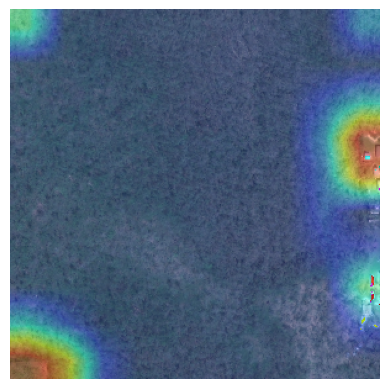

In [50]:
import os

google_drive_damage_folder = "/content/drive/MyDrive/data/damage"

files = os.listdir(google_drive_damage_folder)
image_name = files[0]

perfect_linux_path = os.path.join(google_drive_damage_folder, image_name)

print("Opening image from Google Drive...")
print(f"Path: {perfect_linux_path}")

show_gradcam(perfect_linux_path)

